### Visualize the number of shared DEGs across all sets

In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
cell_types <- c("Adipocyte", "Cardiomyocyte", "Endothelial",
        "Fibroblast", "LEC", "Lymphoid", "Myeloid", "Neuronal", "Pericyte")

all_down_counts <- lapply(cell_types, function(cell_type) {
  df <- read.csv(paste0("ora_results/", cell_type, "_upset_down_counts.csv"))
  df$cell_type <- cell_type
  df
}) %>%
  bind_rows()
all_down_counts$direction <- "down"

all_up_counts <- lapply(cell_types, function(cell_type) {
  df <- read.csv(paste0("ora_results/", cell_type, "_upset_up_counts.csv"))
  df$cell_type <- cell_type
  df
}) %>%
  bind_rows()
all_up_counts$direction <- "up"

In [3]:
all_counts <- rbind(all_up_counts, all_down_counts)

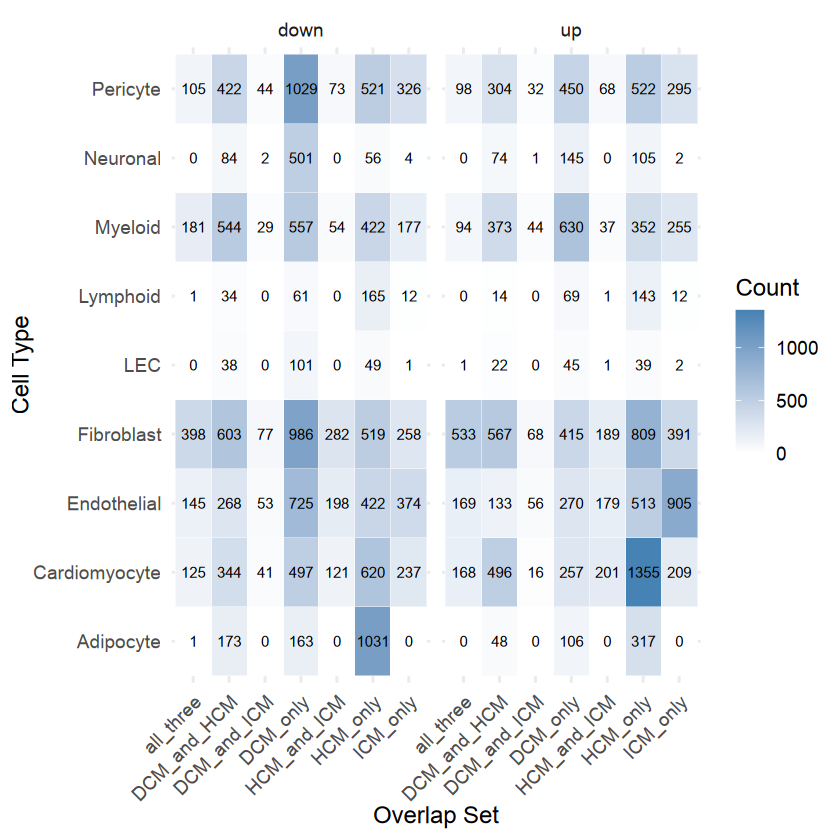

In [9]:
options(repr.plot.width = 7, repr.plot.height = 7)

p1 <- ggplot(all_counts, aes(x = Set, y = cell_type, fill = Count)) + facet_wrap(~ direction) + 
  geom_tile(color = "white") +
  geom_text(aes(label = Count), color = "black", size = 3) +
  scale_fill_gradient(low = "white", high = "steelblue") +
  labs(x = "Overlap Set", y = "Cell Type", fill = "Count") +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

ggsave(p1, filename="02B_shared_DEGs_across_cell_types.pdf", width = 7, height = 7)

p1